## Random Forest - Combined Dataset

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids

# Step 1: Set environment variable to avoid KMeans memory leak (Windows-specific)
os.environ['OMP_NUM_THREADS'] = '5'  # Adjust the number of threads used by KMeans

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Step 2: Load dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
df.drop(columns=["wkt_geom"], inplace=True, errors="ignore")

# Step 3: Prepare features and target variable
X = df.drop(columns=["Target_Var"]).fillna(0)
y = df["Target_Var"]

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Step 5: Apply ClusterCentroids for Undersampling Majority Class
cc = ClusterCentroids(random_state=42, sampling_strategy='auto')  # Automatically balance classes
X_train_res, y_train_res = cc.fit_resample(X_train, y_train)

# Step 6: Apply Borderline SMOTE for Oversampling Minority Class
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')  # Focus on the minority class
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

# Step 7: Standardize the features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Step 8: Feature Selection using RandomForest
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_scaled, y_train_res)
sfm = SelectFromModel(rf_selector, prefit=True, threshold="median")
X_train_selected = sfm.transform(X_train_scaled)
X_test_selected = sfm.transform(X_test_scaled)

# Step 9: Define function for model evaluation
def evaluate_model(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    print(f"\n================ {name} =================")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall:", recall_score(y_true, y_pred, average="weighted"))
    print("AUC ROC (OvR):", roc_auc_score(y_true, model.predict_proba(X_eval), multi_class="ovr"))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# Step 10: Hyperparameter Tuning using GridSearchCV
rf_params = {
    'n_estimators': [15, 30, 50, 75, 100, 150, 200],
    'max_depth': [6, 10, 15, 20, 25, 30]
}
rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=6,
    scoring='accuracy',
    n_jobs=-1
)
rf.fit(X_train_selected, y_train_res)

# Step 11: Evaluate the best model
evaluate_model("Random Forest (Tuned with SMOTE and ClusterCentroids)", rf.best_estimator_, X_test_selected, y_test)


C:\Users\megha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\megha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\megha\anaconda3\Lib\site-packages\sklearn\base.py:1473: ConvergenceWarning: Number of distinct clusters (957) found smaller than n_clusters (1029). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
C:\Users\megha\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\meg


================ Random Forest (Tuned with SMOTE and ClusterCentroids) =================
Accuracy: 0.7196891191709844
Precision: 0.7740174502015273
Recall: 0.7196891191709844
AUC ROC (OvR): 0.9082840085053127
Confusion Matrix:
 [[537 148 280]
 [ 22 378  41]
 [ 34  16 474]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.56      0.69       965
           1       0.70      0.86      0.77       441
           2       0.60      0.90      0.72       524

    accuracy                           0.72      1930
   macro avg       0.73      0.77      0.73      1930
weighted avg       0.77      0.72      0.72      1930



In [10]:
# Retrieve the best hyperparameters and best model
best_params = rf.best_params_
best_model = rf.best_estimator_
print("Best Hyperparameters:", best_params)
print("Best Cross-Validation Score:", rf.best_score_)

Best Hyperparameters: {'max_depth': 15, 'n_estimators': 200}
Best Cross-Validation Score: 0.7946261947036378


In [12]:
rf2 = RandomForestClassifier(random_state=42, n_estimators=3, max_depth=5)

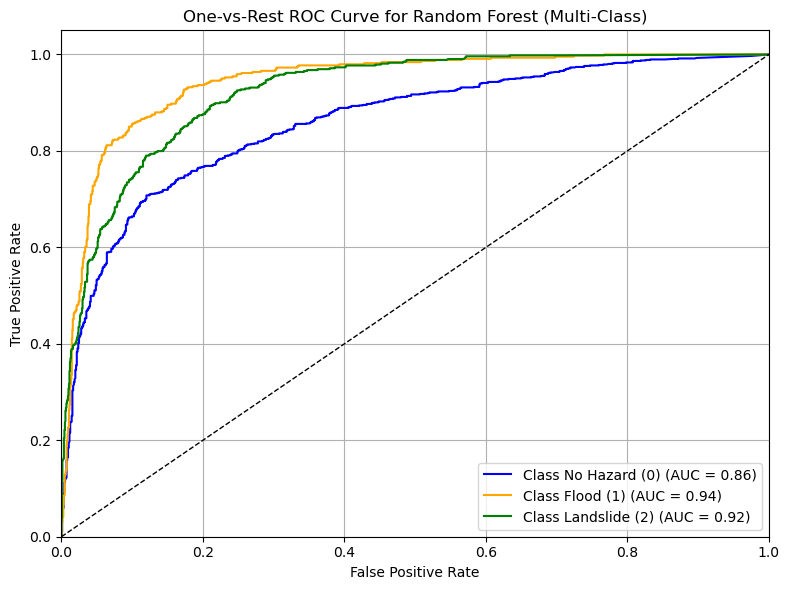

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the output for OvR
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score = rf.best_estimator_.predict_proba(X_test_selected)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
labels = ['No Hazard (0)', 'Flood (1)', 'Landslide (2)']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"Class {labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curve for Random Forest (Multi-Class)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd

# Predict class labels and class probabilities
y_pred_rf = rf.predict(X_test_selected)
y_proba = rf.predict_proba(X_test_selected)

# Create DataFrame for multi-class output
df_rf = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred_rf,
    'Prob_Class_0': y_proba[:, 0],
    'Prob_Class_1': y_proba[:, 1],
    'Prob_Class_2': y_proba[:, 2]
})

# Save to CSV
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\RF_Combined_Results.csv"
df_rf.to_csv(save_path, index=False)

print(f"Saved Random Forest multi-class predictions to {save_path}")


Saved Random Forest multi-class predictions to C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\RF_Combined_Results.csv
